INDIA MAP COLORING PROBLEM - CSP SOLVER

1. PLAIN BACKTRACKING
------------------------------
Solution: {'AP': 'Red', 'AR': 'Red', 'AS': 'Green', 'BR': 'Red', 'CG': 'Red', 'GA': 'Red', 'GJ': 'Red', 'HR': 'Red', 'HP': 'Green', 'JH': 'Green', 'KA': 'Green', 'KL': 'Red', 'MP': 'Green', 'MH': 'Blue', 'MN': 'Red', 'ML': 'Red', 'MZ': 'Blue', 'NL': 'Blue', 'OD': 'Blue', 'PB': 'Blue', 'RJ': 'Yellow', 'SK': 'Red', 'TN': 'Blue', 'TS': 'Yellow', 'TR': 'Yellow', 'UP': 'Blue', 'UK': 'Yellow', 'WB': 'Yellow', 'JK': 'Red'}
Steps explored: 30

2. BACKTRACKING WITH MRV + LCV
----------------------------------------
Solution: {'AP': 'Red', 'KA': 'Green', 'TN': 'Blue', 'KL': 'Red', 'TS': 'Blue', 'MH': 'Red', 'GA': 'Blue', 'OD': 'Green', 'CG': 'Blue', 'JH': 'Red', 'MP': 'Green', 'UP': 'Yellow', 'BR': 'Green', 'RJ': 'Red', 'WB': 'Blue', 'AS': 'Red', 'AR': 'Green', 'NL': 'Blue', 'MN': 'Green', 'MZ': 'Blue', 'TR': 'Green', 'ML': 'Blue', 'GJ': 'Green', 'HR': 'Yellow', 'PB': 'Green', 'HP': 'Red', 'UK': 'Green'

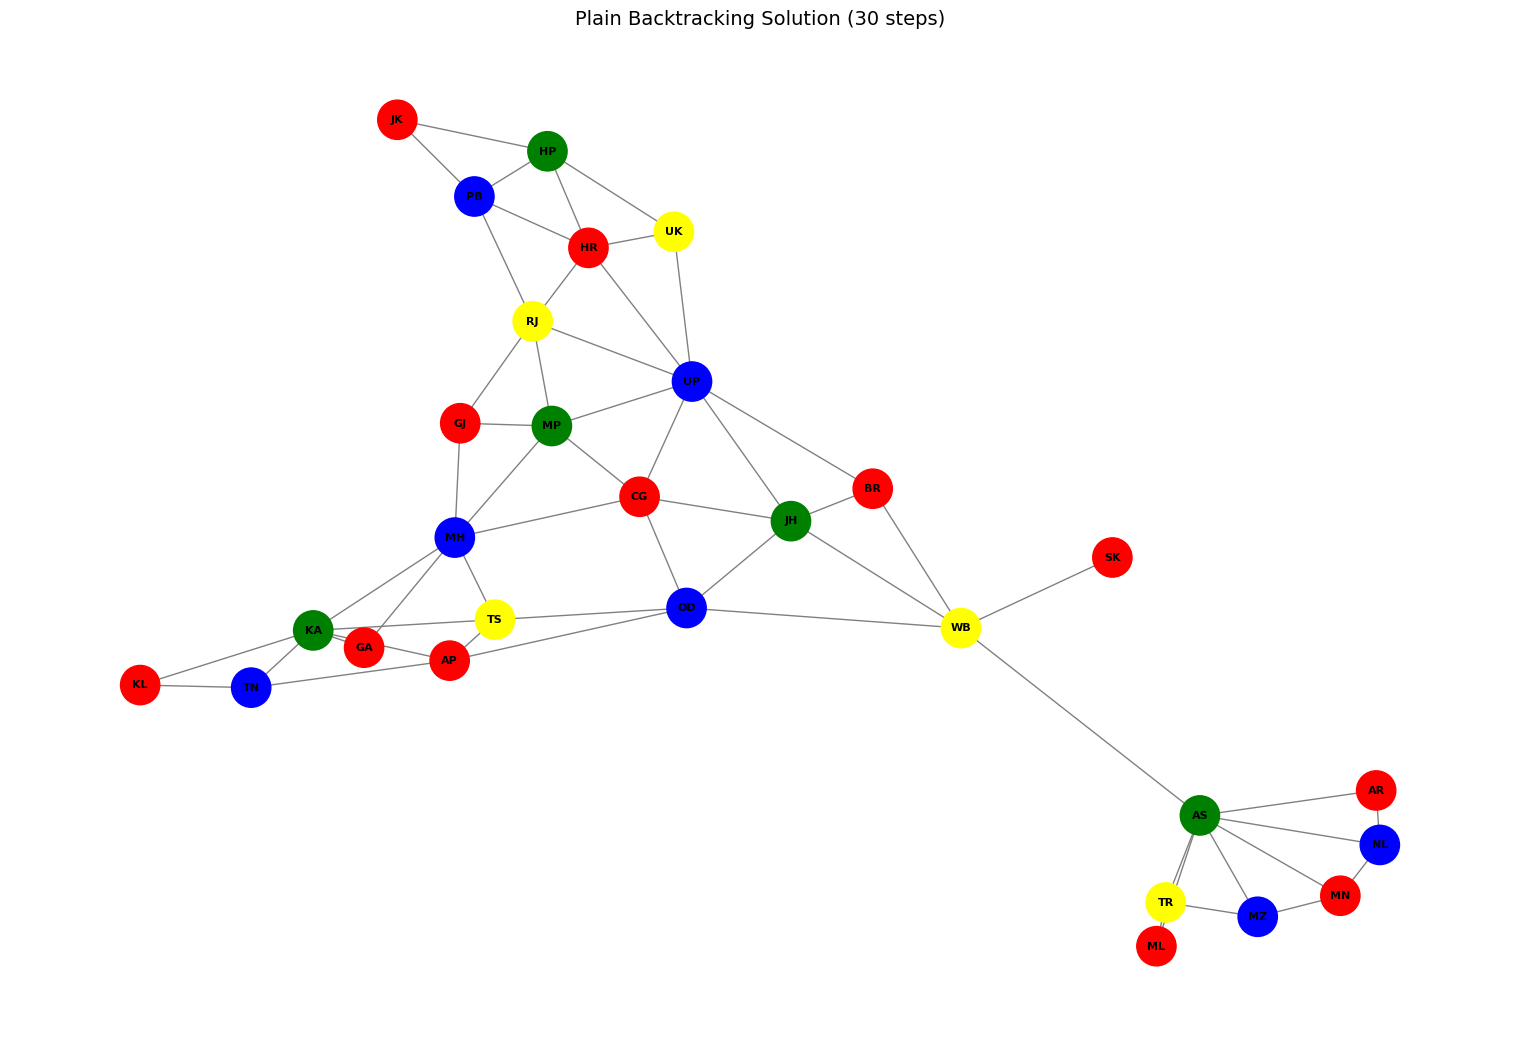

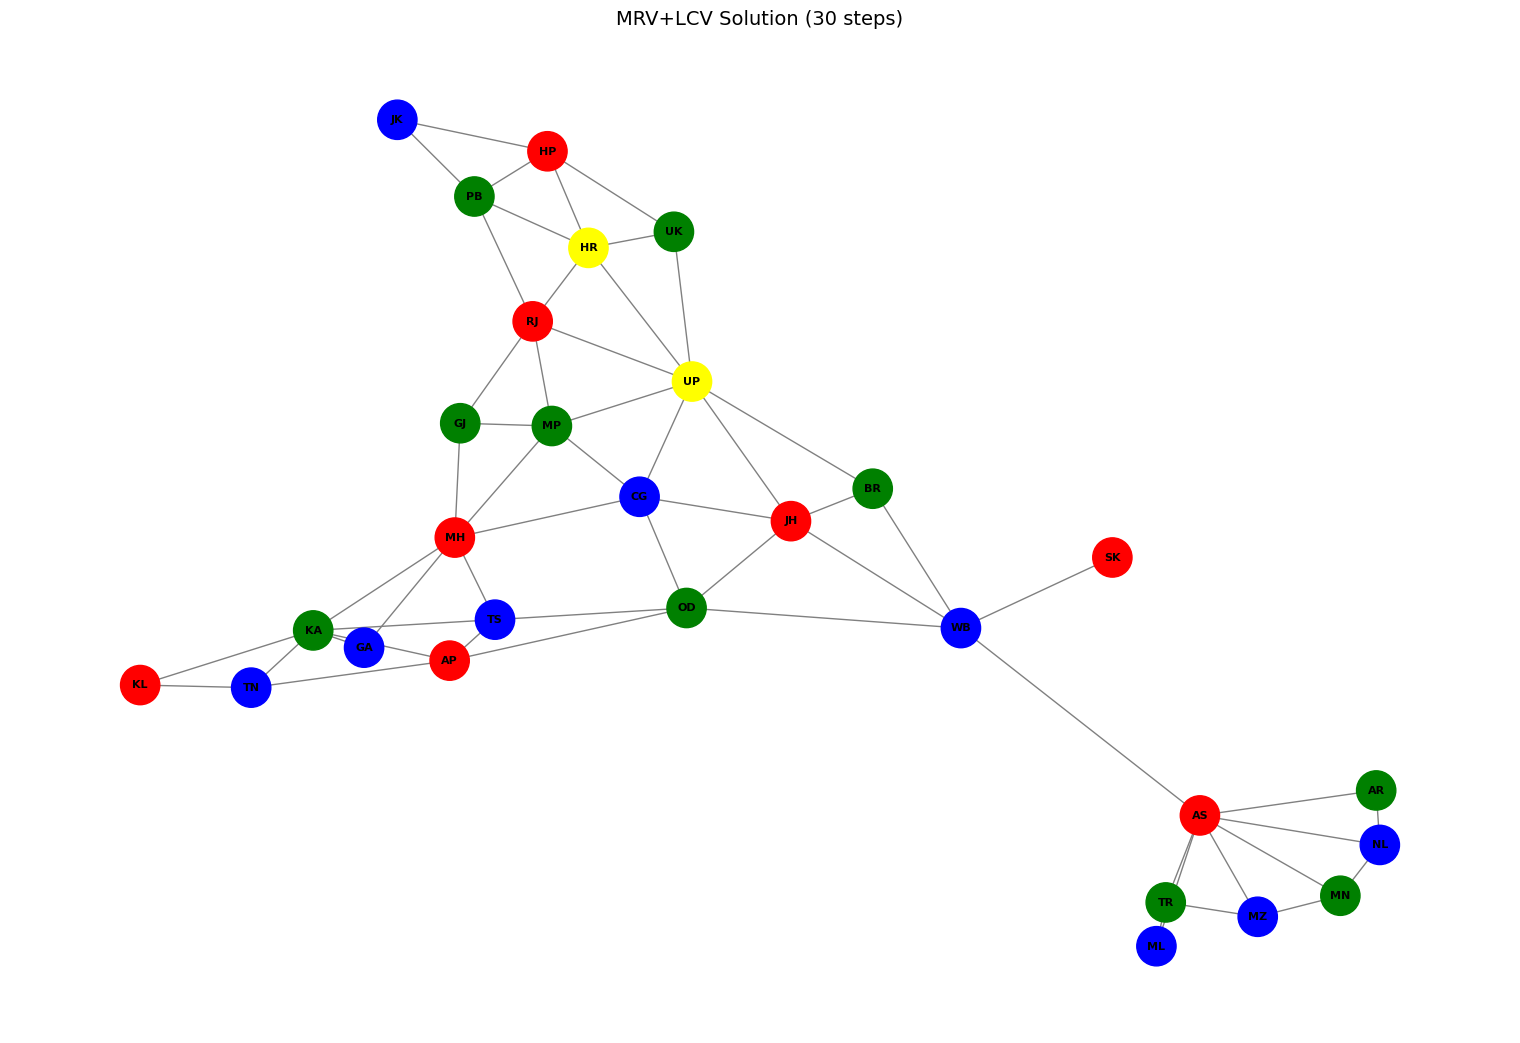

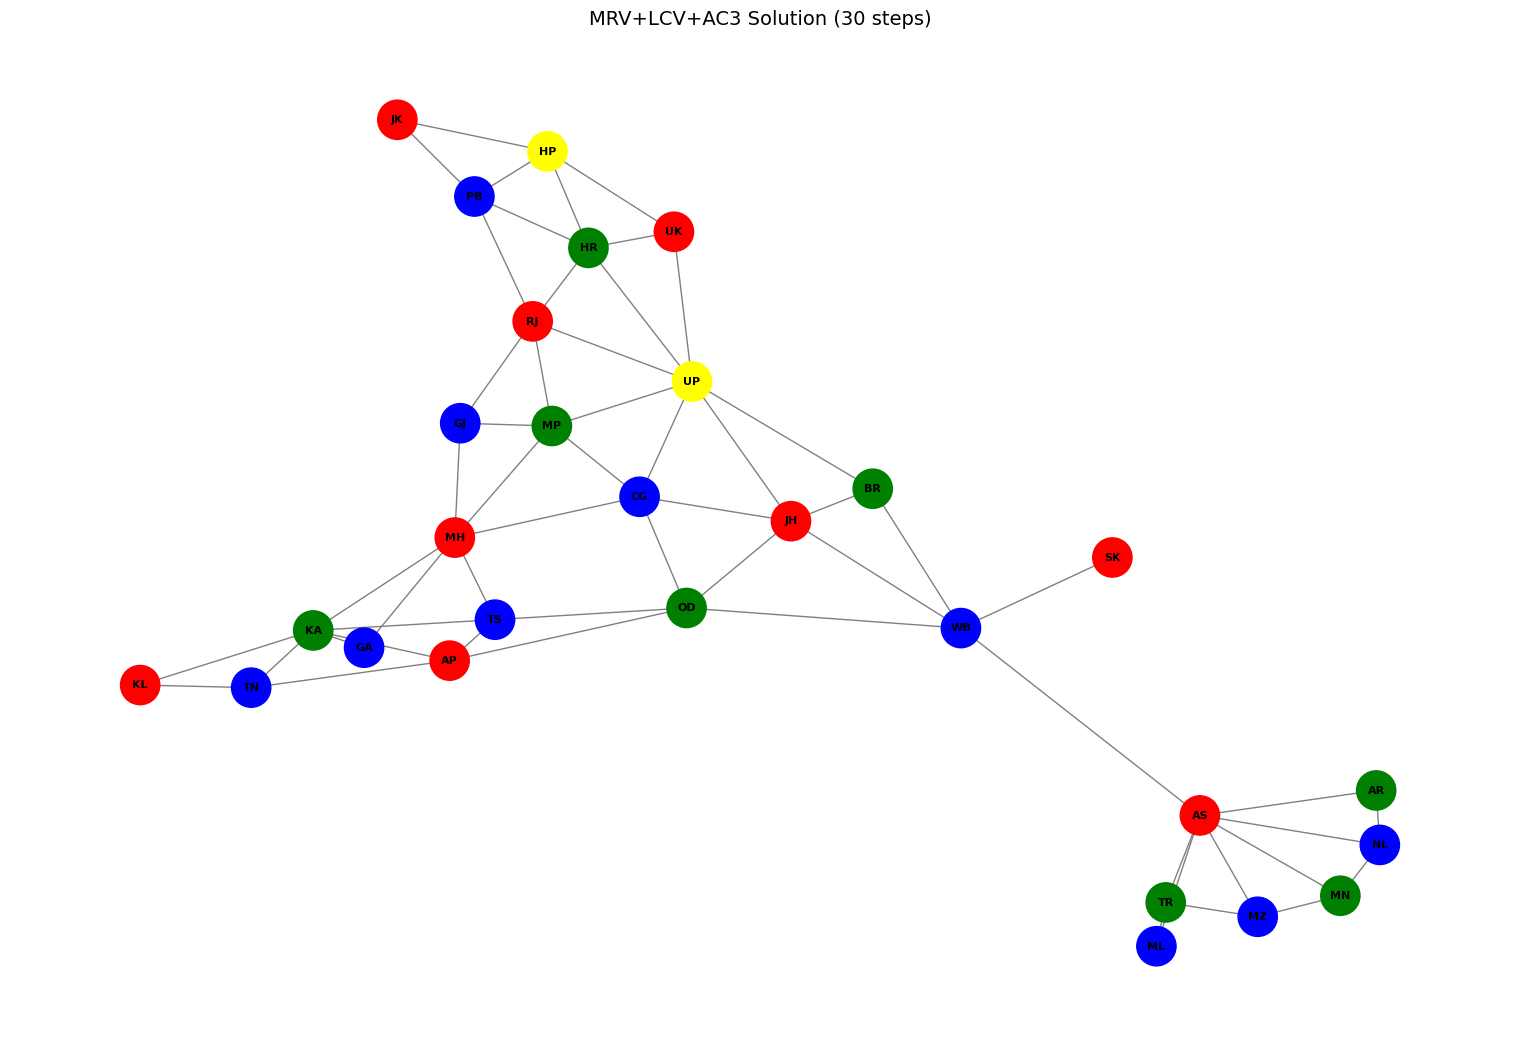

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque
import copy

# India Map Data
variables = ["AP", "AR", "AS", "BR", "CG", "GA", "GJ", "HR", "HP", "JH", "KA",
             "KL", "MP", "MH", "MN", "ML", "MZ", "NL", "OD", "PB", "RJ", "SK",
             "TN", "TS", "TR", "UP", "UK", "WB", "JK"]

colors = ["Red", "Green", "Blue", "Yellow"]

neighbors = {
    "AP": ["TS", "OD", "TN", "KA"],
    "AR": ["AS", "NL"],
    "AS": ["AR", "NL", "ML", "TR", "MZ", "MN", "WB"],
    "BR": ["UP", "JH", "WB"],
    "CG": ["UP", "JH", "OD", "MH"],
    "GA": ["MH", "KA"],
    "GJ": ["MH", "RJ"],
    "HR": ["PB", "HP", "UK", "RJ"],
    "HP": ["JK", "PB", "HR", "UK"],
    "JH": ["BR", "UP", "CG", "OD", "WB"],
    "KA": ["MH", "AP", "TS", "TN", "KL", "GA"],
    "KL": ["KA", "TN"],
    "MP": ["RJ", "UP", "CG", "MH", "GJ"],
    "MH": ["GJ", "MP", "CG", "TS", "KA", "GA"],
    "MN": ["AS", "MZ", "NL"],
    "ML": ["AS", "TR"],
    "MZ": ["AS", "MN", "TR"],
    "NL": ["AR", "AS", "MN"],
    "OD": ["WB", "JH", "CG", "AP", "TS"],
    "PB": ["JK", "HP", "HR", "RJ"],
    "RJ": ["PB", "HR", "MP", "GJ", "UP"],
    "SK": ["WB"],
    "TN": ["AP", "KA", "KL"],
    "TS": ["MH", "KA", "AP", "OD"],
    "TR": ["AS", "ML", "MZ"],
    "UP": ["UK", "HR", "RJ", "MP", "CG", "JH", "BR"],
    "UK": ["HP", "HR", "UP"],
    "WB": ["BR", "JH", "OD", "AS", "SK"],
    "JK": ["HP", "PB"]
}

def is_valid(assignment, var, value):
    for neighbor in neighbors[var]:
        if neighbor in assignment and assignment[neighbor] == value:
            return False
    return True

# ===== 1. PLAIN BACKTRACKING =====
plain_steps = 0

def backtrack_plain(assignment):
    global plain_steps
    plain_steps += 1
    
    if len(assignment) == len(variables):
        return assignment
    
    # Select first unassigned variable (no heuristic)
    unassigned = [v for v in variables if v not in assignment]
    var = unassigned[0]
    
    # Try colors in fixed order (no LCV)
    for value in colors:
        if is_valid(assignment, var, value):
            assignment[var] = value
            result = backtrack_plain(assignment)
            if result is not None:
                return result
            del assignment[var]  # backtrack
    
    return None

# ===== 2. BACKTRACKING WITH MRV + LCV =====
heuristic_steps = 0
mrv_lcv_log = []

def select_unassigned_var_mrv(assignment):
    unassigned = [v for v in variables if v not in assignment]
    def remaining_values(var):
        return sum(1 for color in colors if is_valid(assignment, var, color))
    return min(unassigned, key=remaining_values)

def order_domain_values_lcv(var, assignment):
    def constraining_count(value):
        temp_assignment = assignment.copy()
        temp_assignment[var] = value
        count = 0
        for neighbor in neighbors[var]:
            if neighbor not in assignment:
                for color in colors:
                    if not is_valid(temp_assignment, neighbor, color):
                        count += 1
        return count
    return sorted(colors, key=constraining_count)

def backtrack_heuristic(assignment):
    global heuristic_steps, mrv_lcv_log
    heuristic_steps += 1
    
    if len(assignment) == len(variables):
        return assignment
    
    var = select_unassigned_var_mrv(assignment)
    ordered_values = order_domain_values_lcv(var, assignment)
    
    if heuristic_steps <= 10:  # Log first 10 steps
        mrv_lcv_log.append(f"Step {heuristic_steps}: MRV selected {var}, LCV order: {ordered_values}")
    
    for value in ordered_values:
        if is_valid(assignment, var, value):
            assignment[var] = value
            result = backtrack_heuristic(assignment)
            if result is not None:
                return result
            del assignment[var]  # backtrack
    
    return None

# ===== 3. AC-3 ALGORITHM =====
def ac3(csp_domains):
    queue = deque()
    # Initialize queue with all arcs
    for var in variables:
        for neighbor in neighbors[var]:
            queue.append((var, neighbor))
    
    while queue:
        xi, xj = queue.popleft()
        if revise(csp_domains, xi, xj):
            if len(csp_domains[xi]) == 0:
                return False
            for xk in neighbors[xi]:
                if xk != xj:
                    queue.append((xk, xi))
    return True

def revise(csp_domains, xi, xj):
    revised = False
    for x in csp_domains[xi][:]:  # Copy to avoid modification during iteration
        satisfies = False
        for y in csp_domains[xj]:
            if x != y:  # Different colors
                satisfies = True
                break
        if not satisfies:
            csp_domains[xi].remove(x)
            revised = True
    return revised

# ===== 4. BACKTRACKING WITH MRV + LCV + AC-3 =====
ac3_steps = 0
ac3_log = []

def select_unassigned_var_domain(assignment, domains):
    unassigned = [v for v in variables if v not in assignment]
    return min(unassigned, key=lambda var: len(domains[var]))

def order_domain_values_lcv_ac3(var, assignment, domains):
    def constraining_count(value):
        count = 0
        for neighbor in neighbors[var]:
            if neighbor not in assignment and value in domains[neighbor]:
                count += 1
        return count
    return sorted(domains[var], key=constraining_count)

def backtrack_ac3(assignment, domains):
    global ac3_steps, ac3_log
    ac3_steps += 1
    
    if len(assignment) == len(variables):
        return assignment
    
    var = select_unassigned_var_domain(assignment, domains)
    ordered_values = order_domain_values_lcv_ac3(var, assignment, domains)
    
    if ac3_steps <= 10:  # Log first 10 steps
        ac3_log.append(f"Step {ac3_steps}: MRV selected {var}, LCV order: {ordered_values}")
    
    for value in ordered_values:
        if is_valid(assignment, var, value):
            # Make assignment
            assignment[var] = value
            
            # Copy domains and apply constraint
            new_domains = {v: domains[v][:] for v in domains}
            new_domains[var] = [value]
            
            # Apply AC-3
            if ac3(new_domains):
                result = backtrack_ac3(assignment, new_domains)
                if result is not None:
                    return result
            
            # Backtrack
            del assignment[var]
    
    return None

def visualize_coloring(solution, title):
    if not solution:
        print("No solution to visualize")
        return
        
    G = nx.Graph()
    for var in variables:
        G.add_node(var)
    for var, neighs in neighbors.items():
        for neighbor in neighs:
            G.add_edge(var, neighbor)
    
    pos = nx.spring_layout(G, seed=42)
    node_colors = [solution.get(node, "white") for node in G.nodes()]
    
    plt.figure(figsize=(15, 10))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=800, font_size=8, font_weight="bold", edge_color="gray")
    plt.title(title, fontsize=14)
    plt.show()

if __name__ == "__main__":
    print("="*50)
    print("INDIA MAP COLORING PROBLEM - CSP SOLVER")
    print("="*50)
    
    # 1. Plain Backtracking
    print("\n1. PLAIN BACKTRACKING")
    print("-" * 30)
    plain_steps = 0
    plain_solution = backtrack_plain({})
    print(f"Solution: {plain_solution}")
    print(f"Steps explored: {plain_steps}")
    
    # 2. MRV + LCV Heuristic
    print("\n2. BACKTRACKING WITH MRV + LCV")
    print("-" * 40)
    heuristic_steps = 0
    mrv_lcv_log = []
    heuristic_solution = backtrack_heuristic({})
    print(f"Solution: {heuristic_solution}")
    print(f"Steps explored: {heuristic_steps}")
    print("\nMRV/LCV Decision Log (first 10 steps):")
    for log in mrv_lcv_log:
        print(f"  {log}")
    
    # 3. MRV + LCV + AC-3
    print("\n3. BACKTRACKING WITH MRV + LCV + AC-3")
    print("-" * 45)
    ac3_steps = 0
    ac3_log = []
    initial_domains = {var: colors[:] for var in variables}
    ac3_solution = backtrack_ac3({}, initial_domains)
    print(f"Solution: {ac3_solution}")
    print(f"Steps explored: {ac3_steps}")
    print("\nMRV/LCV Decision Log with AC-3 (first 10 steps):")
    for log in ac3_log:
        print(f"  {log}")
    
    # Results Table
    print("\n" + "="*50)
    print("RESULTS COMPARISON")
    print("="*50)
    print("| Algorithm                    | Steps Explored |")
    print("|------------------------------|----------------|")
    print(f"| Plain Backtracking           | {plain_steps:>13} |")
    print(f"| MRV + LCV Heuristic          | {heuristic_steps:>13} |")
    print(f"| MRV + LCV + AC-3             | {ac3_steps:>13} |")
    
    # Analysis
    print("\nANALYSIS:")
    print("-" * 20)
    if plain_steps > heuristic_steps:
        print("✓ MRV+LCV reduces search space compared to plain backtracking")
    if heuristic_steps > ac3_steps:
        print("✓ AC-3 further reduces search space by early constraint propagation")
    if plain_steps == heuristic_steps == ac3_steps:
        print("⚠ All algorithms show same steps - problem may be too easy with 4 colors")
        print("  Consider reducing colors to 3 for more interesting results")
    
    # Visualizations
    print("\nGenerating visualizations...")
    if plain_solution:
        visualize_coloring(plain_solution, f"Plain Backtracking Solution ({plain_steps} steps)")
    if heuristic_solution:
        visualize_coloring(heuristic_solution, f"MRV+LCV Solution ({heuristic_steps} steps)")
    if ac3_solution:
        visualize_coloring(ac3_solution, f"MRV+LCV+AC3 Solution ({ac3_steps} steps)")
